### Importing the libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import mlflow
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score
from imblearn.over_sampling import SMOTE


### Loading the dataset

In [2]:
data = pd.read_csv('../data/raw_data/diabetes_012_health_indicators_BRFSS2015.csv')

pd.set_option('display.max_columns', None)

data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Data preprocessing

In [3]:
# duplicate data (23899) => drop the duplicate
# outlier(BMI, PhysHIth, GenHIth, MentHIth) => scale the data
# class imbalance => use the class wight in the algorithm

In [4]:
new_data = data.copy()

In [5]:
new_data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [6]:
# drop the duplicate
new_data.drop_duplicates(inplace = True)

In [7]:
new_data.shape

(229781, 22)

In [8]:
# rename the columns
new_data.rename(columns = {'Diabetes_012': 'DiabetesPrediction'}, inplace = True)
new_data.head()

,DiabetesPrediction,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [9]:
def convert_datatypes(data, cols):
    for col in cols:
        data[col] = data[col].astype(int)
    return data

new_data = convert_datatypes(new_data, new_data.columns)

In [10]:
new_data.to_csv('../data/new_data/new_data.csv', index = False)

In [11]:
new_data.query('DiabetesPrediction == 1')

,DiabetesPrediction,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
64,1,1,1,1,27,0,0,0,1,1,1,0,1,1,4,30,30,1,0,10,4,3
81,1,1,1,1,33,0,0,0,0,0,1,0,1,0,3,3,0,0,1,7,4,7
193,1,1,1,1,34,0,0,0,0,0,1,0,1,0,2,0,0,0,0,7,4,8
236,1,1,1,1,33,1,0,0,0,1,1,0,1,0,5,30,30,1,0,12,6,6
275,1,1,1,1,32,1,1,0,1,0,1,0,1,0,5,0,30,1,1,8,5,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253528,1,1,0,1,34,0,0,0,1,1,1,0,1,0,3,0,6,0,0,4,5,4
253529,1,1,0,1,32,1,0,0,1,0,1,0,1,0,2,0,2,0,1,9,6,7
253566,1,0,0,1,24,0,0,1,0,1,1,0,1,0,3,0,0,0,0,10,6,4
253664,1,0,1,1,29,1,0,0,0,0,0,0,1,0,3,0,0,0,0,6,6,4


### Feature engineering

In [12]:
# For now there is no feature in my mind to add to this data
# but maybe later

### Build the Model

In [13]:
X = new_data.drop(labels = 'DiabetesPrediction', axis = 1)
y = new_data.loc[:, 'DiabetesPrediction']

In [14]:
X.drop(labels = ['Education', 'Income'], axis = 1, inplace = True)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 42, shuffle = True, stratify = y)

In [16]:
type(X_test)

pandas.core.frame.DataFrame

In [17]:
print(y_test[2])
print(X_test.iloc[2, :].tolist())

0
[1, 1, 1, 20, 1, 1, 1, 0, 1, 1, 0, 1, 0, 3, 0, 0, 1, 0, 8]


In [16]:
# scaler = StandardScaler()

# columns = ['BMI', 'PhysHlth', 'GenHlth', 'MentHlth', 'Age']

# X_train[columns] = scaler.fit_transform(X_train[columns])
# X_test[columns] = scaler.transform(X_test[columns])


In [17]:
# smote = SMOTE(random_state = 42)

# X_train_smote, y_train_smote = smote.fit_resample(X = X_train, y = y_train)


#### RandomForestClassifier

In [36]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment('random_forest_classifier_1')

with mlflow.start_run(run_name = 'rdc_param4'):

    param = {'n_jobs': 1, 'n_estimators': 100, 'random_state': 42}

    mlflow.log_params(param)

    rdc = RandomForestClassifier(**param)

    rdc.fit(X_train, y_train)

    y_pred = rdc.predict(X_test)

    # mlflow.sklearn.save_model(rdc, 'rdc.pkl')
    # with open('rdc.pkl', 'wb') as f:
    #     pickle.dump(rdc, f)

    # mlflow.log_artifact('rdc.pkl')

    mlflow.sklearn.log_model(rdc, name = 'rdc_model')

    mlflow.log_metric('Accuracy', accuracy_score(y_test, y_pred))

    mlflow.log_metric('Precession', precision_score(y_test, y_pred, average = 'weighted'))

    mlflow.log_metric('Recall', recall_score(y_test, y_pred, average = 'weighted'))

    mlflow.log_metric('F1', f1_score(y_test, y_pred, average = 'weighted'))




🏃 View run rdc_param4 at: http://127.0.0.1:5000/#/experiments/1/runs/8b3a9cfaa8b14c018fffcc512b5305dd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [37]:
loaded = mlflow.sklearn.load_model('runs:/8b3a9cfaa8b14c018fffcc512b5305dd/rdc_model')


In [38]:
user_data = [[1, 1, 1, 32, 1, 1, 0, 1, 0, 1, 0, 1, 0, 5, 0, 30, 1, 1, 8]]

loaded.predict(user_data)

c:\AI_Student\machine_learning_engineer\projects\ML_end_to_end\diabetes_risk_prediction_system\venv_diabetes_risk_prediction_project\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [18]:
rdc = RandomForestClassifier(n_jobs = 1, n_estimators = 100, random_state = 42)

rdc.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [19]:
y_pred = rdc.predict(X_test)

In [20]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[54091,   129,  2797],
       [ 1207,     4,   178],
       [ 8211,    30,  2288]])

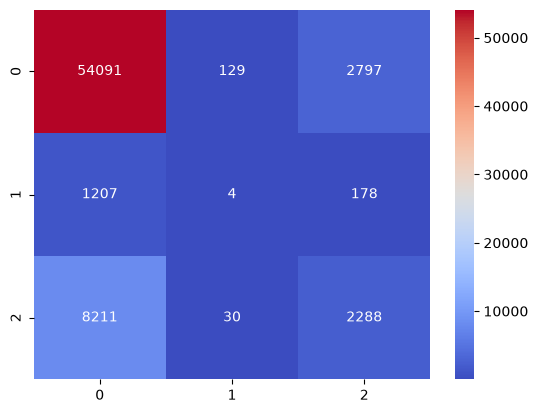

In [21]:
sns.heatmap(cm, annot = True, fmt = '.0f', cmap = 'coolwarm')
plt.show()

In [22]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='micro')

print(f'The accuracy of the model: {accuracy* 100:.0f}%')
print(f'The f1 score: {f1*100:.0f}%')

The accuracy of the model: 82%
The f1 score: 82%


In [23]:
class_report = classification_report(y_test, y_pred, output_dict = True)
class_report  = pd.DataFrame(class_report).transpose()
class_report

,precision,recall,f1-score,support
0,0.851706,0.948682,0.897582,57017.000000
1,0.024540,0.002880,0.005155,1389.000000
2,0.434733,0.217305,0.289767,10529.000000
accuracy,0.817915,0.817915,0.817915,0.817915
macro avg,0.436993,0.389622,0.397501,68935.000000
weighted avg,0.771351,0.817915,0.786764,68935.000000


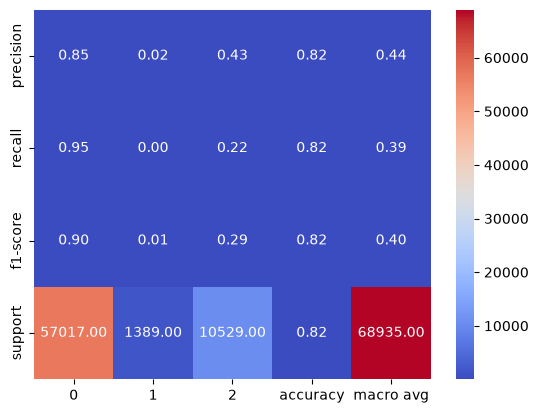

In [24]:
sns.heatmap(class_report.iloc[:-1, :].T, annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.show()

In [25]:
user_data = [[1, 1, 1, 32, 1, 1, 0, 1, 0, 1, 0, 1, 0, 5, 0, 30, 1, 1, 8]]

rdc.predict(user_data)


c:\AI_Student\machine_learning_engineer\projects\ML_end_to_end\diabetes_risk_prediction_system\venv_diabetes_risk_prediction_project\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

#### Save the model

In [26]:
# save the model
with open(r'../models/model.pkl', 'wb') as f:
    pickle.dump(rdc, f)